In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import Series,DataFrame

import seaborn as sb
sb.set_style('whitegrid')



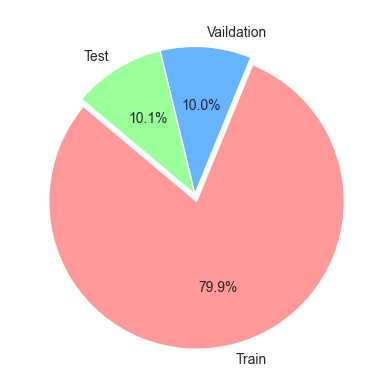

,Survived
0,0
1,0
2,0
3,0
4,0


In [2]:
from pathlib import Path


def get_output_path(filename):
    return Path().resolve().parent / 'output' / filename

# save dataset data

x_train = pd.read_csv(get_output_path('x_train.csv'))
y_train = pd.read_csv(get_output_path('y_train.csv'))
x_test = pd.read_csv(get_output_path('x_test.csv'))
y_test = pd.read_csv(get_output_path('y_test.csv'))
x_val = pd.read_csv(get_output_path('x_val.csv'))
y_val = pd.read_csv(get_output_path('y_val.csv'))

labels  = ['Train','Vaildation','Test']
sizes = [round(len(x_train)),round(len(x_val)),round(len(x_test))]
colors = ['#ff9999','#66b3ff','#99ff99']

plt.pie(sizes,labels=labels,autopct= '%1.1f%%',colors=colors,startangle=140,explode=(0.05,0,0))

plt.show()


y_train.head()


Survived Survived
0    444
1    268
Name: count, dtype: int64


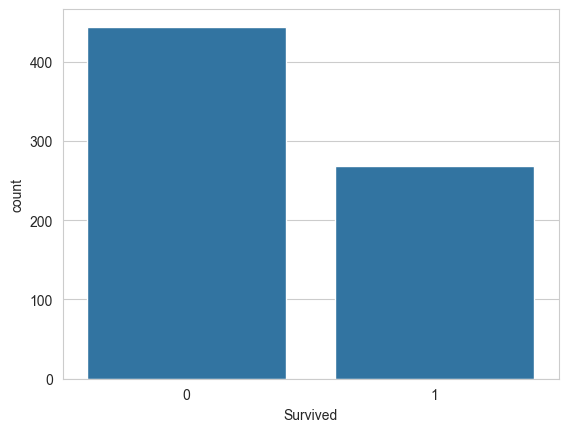

In [3]:
sb.countplot(x='Survived',data=y_train)

print('Survived',y_train['Survived'].value_counts())

In [4]:
# mini pipline

from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder



numeric_features = ['Age', 'Fare', 'FamilySize']
categoric_features = ['Sex', 'Pclass', 'Title', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessors = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categoric', categoric_transformer, categoric_features),
    ]
) 

model = Pipeline(
    [
        ('preprocessor',preprocessors),
        ('classifier',LogisticRegression())
    ]
    
)


In [5]:
model.fit(x_train,y_train)


C:\Users\denis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categoric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
model.score(x_test,y_test)

0.7555555555555555

In [7]:
survival = model.predict(x_test)

print("ok", sum(survival!=0))
print("not ok",sum(survival==0))

ok 36
not ok 54


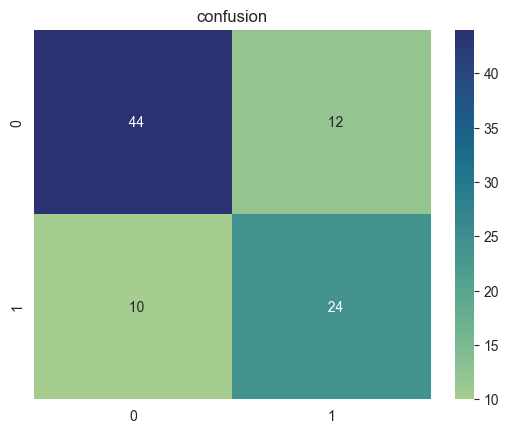

In [8]:
# confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,survival)
sb.heatmap(cm,annot=True,fmt='4.0f',cmap='crest')
plt.title('confusion',size=12)
plt.show()

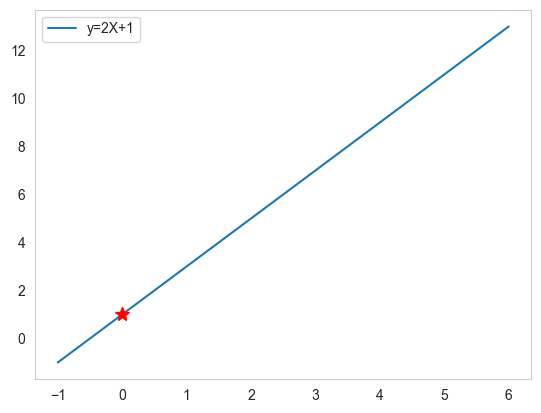

In [9]:
# simple linear  regression demo

X = np.arange(-1,7)
a = 2
b = 1
y = a*X+b

plt.plot(X,y,label=f'y={a}X+{b}')
plt.plot([0],[b], 'r*',markersize=10)
plt.grid()
plt.legend()

In [10]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X_blob, y_bloc = make_blobs(
    n_samples=50,
    n_features=3,
    centers=2,
    cluster_std=1.5,
    random_state=42,

) 

print(f"x shape {X_blob.shape}")
print(f"y shape {np.unique}")


print(X_blob)




x shape (50, 3)
y shape <function unique at 0x00000194B3184160>
[[ 2.36299388e+00 -5.70689288e+00 -8.73553566e+00]
 [ 1.68462824e+00 -6.42730618e+00 -6.93217725e+00]
 [ 1.62128898e+00 -9.00268330e+00 -7.51107758e+00]
 [-2.19590223e+00  6.07478094e+00  2.64759976e+00]
 [-3.41175754e+00  1.17927034e+01  4.61963300e+00]
 [ 2.57924597e+00 -4.05034834e+00 -6.61824287e+00]
 [ 1.21795620e+00 -9.20562234e+00 -6.77726513e+00]
 [-4.09576402e+00  1.02481035e+01  2.80861336e+00]
 [-1.29606910e-01 -5.99934155e+00 -3.59442615e+00]
 [ 3.15971760e+00 -8.24370837e+00 -4.77591813e+00]
 [ 1.48167646e+00 -7.46778942e+00 -9.07538202e+00]
 [-1.99377019e+00  6.36972590e+00  5.12600479e+00]
 [ 2.32155023e+00 -6.44001848e+00 -7.95163672e+00]
 [ 2.41735010e+00 -6.48804428e+00 -6.87243941e+00]
 [-2.37155646e+00  6.03293276e+00  4.31037100e+00]
 [-3.87123374e+00  6.89583058e+00  6.83835199e+00]
 [-7.51523569e-03 -6.09671484e+00 -6.43463258e+00]
 [ 3.19344551e+00 -8.72592367e+00 -6.53891969e+00]
 [ 2.46629635e+00 

before scaler [ 2.36299388 -5.70689288 -8.73553566]
after scaler [ 1.09592498 -0.82676804 -1.28659866]


C:\Users\denis\AppData\Local\Temp\ipykernel_13928\3020657975.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


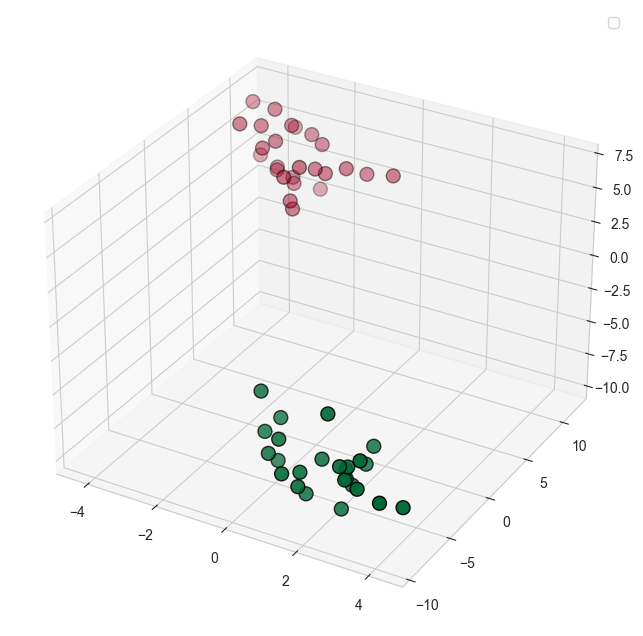

In [11]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()   
X_scaled = scaler.fit_transform(X_blob)


print(f"before scaler {X_blob[0]}")
print(f"after scaler {X_scaled[0]}")


fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_blob[:, 0], X_blob[:, 1],X_blob[:, 2], c=y_bloc, s=100, edgecolors='black', cmap='RdYlGn')


plt.grid(True)

plt.legend()

[[-0.76127322]
 [-1.41869179]
 [ 0.45129046]
 [-0.77111621]
 [ 0.23820651]
 [ 1.71873313]
 [ 0.41169756]
 [-0.82914259]
 [ 0.11046641]
 [ 0.69649121]
 [ 0.53760054]
 [-0.587295  ]
 [-3.1882251 ]
 [ 0.12046015]
 [ 1.16915177]
 [ 0.41580869]
 [-0.2402943 ]
 [ 0.93843451]
 [ 1.10014328]
 [ 0.10098614]
 [-1.21878863]
 [ 0.27863321]
 [ 0.79977834]
 [-0.54989369]
 [ 0.47683863]]
[0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1 0 1]


C:\Users\denis\AppData\Local\Temp\ipykernel_13928\2535099648.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


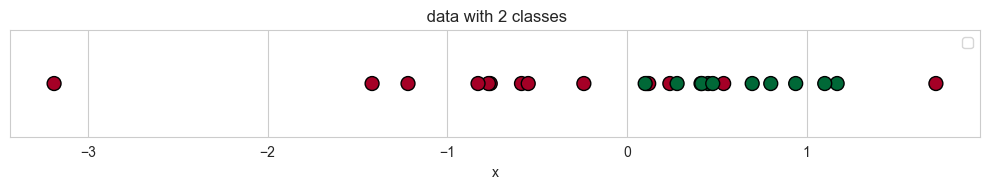

In [12]:
from sklearn.datasets import make_classification


X,y = make_classification(
    n_samples=25,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    random_state=11,
    n_clusters_per_class=1,
    class_sep=0.4
)


scaler = StandardScaler(

)
X = scaler.fit_transform(X)

print(X),
print(y)

plt.figure(figsize=(10,2))
plt.scatter(X,np.zeros_like(X),c=y,s=100,edgecolors='black',cmap='RdYlGn')
plt.xlabel('x')
plt.title(f' data with {len(np.unique(y))} classes')
plt.yticks([])
plt.tight_layout()
plt.legend()



In [13]:
from sklearn.linear_model import LogisticRegression 

model = LogisticRegression(random_state=42)
model.fit(X,y.ravel())

model.coef_, model.intercept_

(array([[1.34494091]]), array([-0.19801197]))

In [ ]:
# in thist 


y_pred = model.predict(X)

y_proba = model.predict_proba(X)[:,1]

y_from_proba = (y_proba>=0.5).astype(int)
assert np.all(y_pred==y_from_proba) ,"not the same"

for i in range(5):
    print(f"true {y[i]}, pred {y_pred[i]}, proba {y_proba[i]}, from proba {y_from_proba[i]}")

true 0, pred 0, proba 0.2276058695763228, from proba 0
true 0, pred 0, proba 0.10850838346141464, from proba 0
true 1, pred 1, proba 0.6008353696911444, from proba 1
true 0, pred 0, proba 0.22528696209377816, from proba 0
true 0, pred 1, proba 0.5305523187359933, from proba 1


In [27]:

def sigmoid(x: np.ndarray) -> np.ndarray:

    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


test_inputs = np.array([-1000, -3, -1, 0, 1, 3, 1000])
print("z → sigmoid(z):")
for z in test_inputs:
    print(f"  sigmoid({z}) = {sigmoid(z):.2f}")

z → sigmoid(z):
  sigmoid(-1000) = 0.00
  sigmoid(-3) = 0.05
  sigmoid(-1) = 0.27
  sigmoid(0) = 0.50
  sigmoid(1) = 0.73
  sigmoid(3) = 0.95
  sigmoid(1000) = 1.00


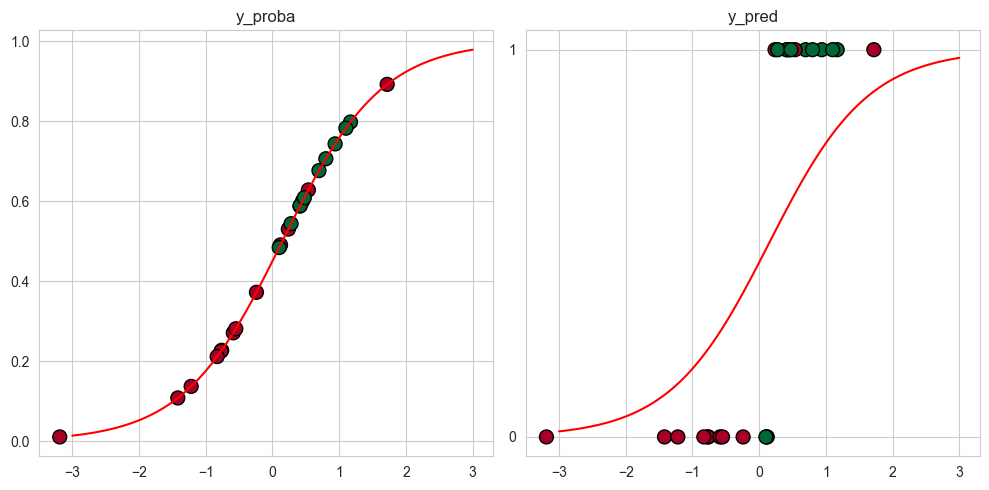

In [56]:
model_a = model.coef_[0]
model_b = model.intercept_[0]


fig,axes = plt.subplots(1,2,figsize=(10,5))


x_line = np.linspace(-3,3,num=100)
model_y_sk = model_a * x_line + model_b



axes[0].plot(x_line,sigmoid(model_y_sk),c='r')
axes[0].scatter(X,y_proba,c=y,s=100,edgecolors='black',cmap='RdYlGn')
axes[0].set_title('y_proba')


axes[1].plot(x_line,sigmoid(model_y_sk),c='r')
axes[1].scatter(X,y_pred,c=y,s=100,edgecolors='black',cmap='RdYlGn')
axes[1].set_yticks([0,1])
axes[1].set_title('y_pred')

plt.tight_layout()
plt.show()